### Imports sys

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader  import load_all
from src.data.cleaner import clean_medals, clean_countries

### Load data

In [2]:
medals, countries = load_all(config_path='../config/config.yaml')
print('Medals shape   :', medals.shape)
print('Countries shape:', countries.shape)

✅ Medals loaded: (36935, 12) | Countries: (201, 5)
   Summer records : 31,165
   Winter records : 5,770
   Project root used: C:\Users\ACER\OneDrive\Desktop\Bull\Olympics-ML-Analysis
Medals shape   : (36935, 12)
Countries shape: (201, 5)


### Preview medals

In [3]:
medals.head(10)

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country,Season
0,0,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,100M Freestyle,Gold,Hungary,Summer
1,1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria,Summer
2,2,1896,Athens,Aquatics,Swimming,Dimitrios Drivas,GRE,Men,100M Freestyle For Sailors,Bronze,Greece,Summer
3,3,1896,Athens,Aquatics,Swimming,Ioannis Malokinis,GRE,Men,100M Freestyle For Sailors,Gold,Greece,Summer
4,4,1896,Athens,Aquatics,Swimming,Spiridon Chasapis,GRE,Men,100M Freestyle For Sailors,Silver,Greece,Summer
5,5,1896,Athens,Aquatics,Swimming,Efstathios Chorophas,GRE,Men,1200M Freestyle,Bronze,Greece,Summer
6,6,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,1200M Freestyle,Gold,Hungary,Summer
7,7,1896,Athens,Aquatics,Swimming,Joannis Andreou,GRE,Men,1200M Freestyle,Silver,Greece,Summer
8,8,1896,Athens,Aquatics,Swimming,Efstathios Chorophas,GRE,Men,400M Freestyle,Bronze,Greece,Summer
9,9,1896,Athens,Aquatics,Swimming,Paul Neumann,AUT,Men,400M Freestyle,Gold,Austria,Summer


### Preview countries

In [4]:
countries.head(10)

,Unnamed: 0,Country,Code,Population,GDP per Capita
0,0,Afghanistan,AFG,32526562.0,594.323081
1,1,Albania,ALB,2889167.0,3945.217582
2,2,Algeria,ALG,39666519.0,4206.031232
3,3,American Samoa*,ASA,55538.0,NaN
4,4,Andorra,AND,70473.0,NaN
5,5,Angola,ANG,25021974.0,4101.472152
6,6,Antigua and Barbuda,ANT,91818.0,13714.731962
7,7,Argentina,ARG,43416755.0,13431.878340
8,8,Armenia,ARM,3017712.0,3489.127690
9,9,Aruba*,ARU,103889.0,NaN


### Basic info

In [5]:
medals.info()

<class 'pandas.DataFrame'>
RangeIndex: 36935 entries, 0 to 36934
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  36935 non-null  int64
 1   Year        36935 non-null  int64
 2   City        36935 non-null  str  
 3   Sport       36935 non-null  str  
 4   Discipline  36935 non-null  str  
 5   Athlete     36935 non-null  str  
 6   Code        31161 non-null  str  
 7   Gender      36935 non-null  str  
 8   Event       36935 non-null  str  
 9   Medal       36935 non-null  str  
 10  Country     31512 non-null  str  
 11  Season      36935 non-null  str  
dtypes: int64(2), str(10)
memory usage: 3.4 MB


### Missing values

In [6]:
print('--- Missing values in medals ---')
print(medals.isnull().sum())
print('\n--- Missing values in countries ---')
print(countries.isnull().sum())

--- Missing values in medals ---
Unnamed: 0       0
Year             0
City             0
Sport            0
Discipline       0
Athlete          0
Code          5774
Gender           0
Event            0
Medal            0
Country       5423
Season           0
dtype: int64

--- Missing values in countries ---
Unnamed: 0         0
Country            0
Code               0
Population         5
GDP per Capita    25
dtype: int64


### Medal distribution

In [7]:
print(medals['Medal'].value_counts())

Medal
Gold      12407
Bronze    12288
Silver    12240
Name: count, dtype: int64


### Season distribution

In [8]:
print(medals['Season'].value_counts())

Season
Summer    31165
Winter     5770
Name: count, dtype: int64


### Unique years

In [9]:
print('Summer years:', sorted(medals[medals['Season']=='Summer']['Year'].unique()))
print('Winter years:', sorted(medals[medals['Season']=='Winter']['Year'].unique()))

Summer years: [1896, 1900, 1904, 1908, 1912, 1920, 1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012]
Winter years: [1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1994, 1998, 2002, 2006, 2010, 2014]


### Top 10 countries by total medals

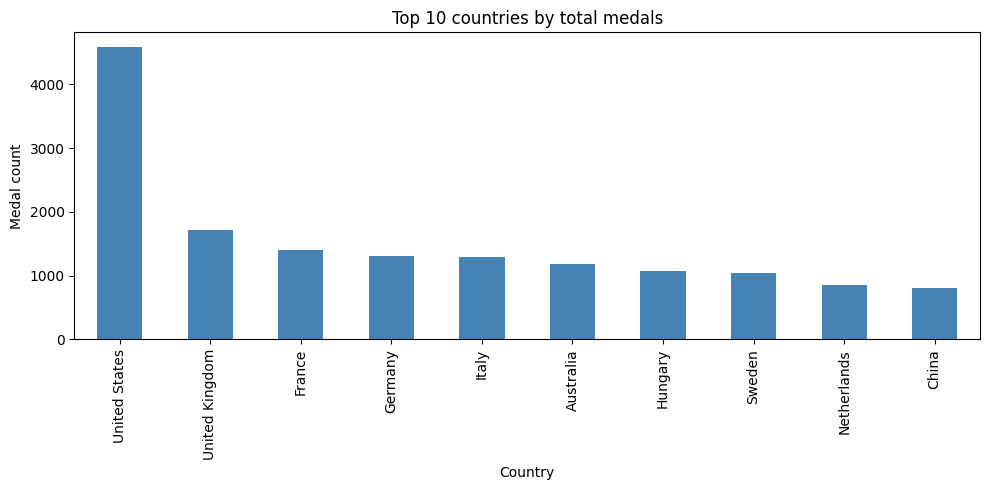

In [10]:
top10 = medals['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 countries by total medals')
ax.set_xlabel('Country')
ax.set_ylabel('Medal count')
plt.tight_layout()
plt.show()

### Medals over years

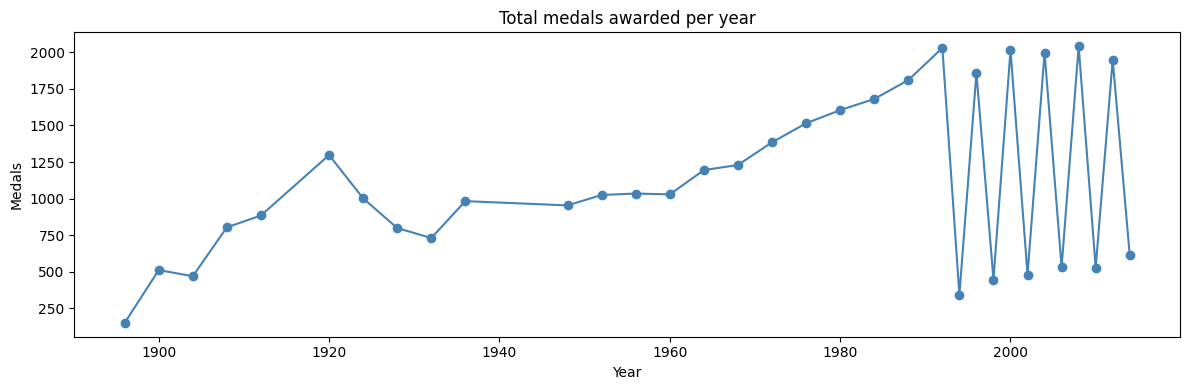

In [11]:
yearly = medals.groupby('Year')['Medal'].count()
fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(ax=ax, marker='o', color='steelblue')
ax.set_title('Total medals awarded per year')
ax.set_xlabel('Year')
ax.set_ylabel('Medals')
plt.tight_layout()
plt.show()

### Gold medals by country

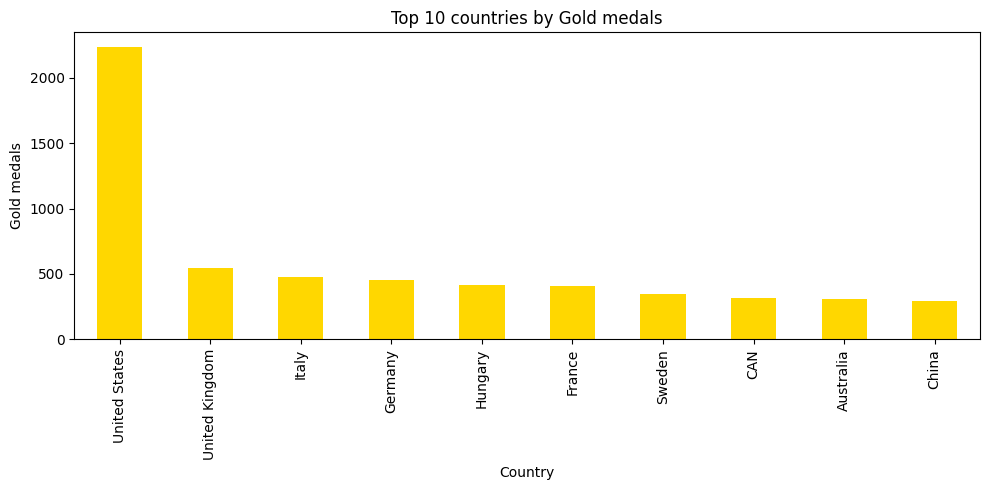

In [12]:
gold = medals[medals['Medal'] == 'Gold']['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
gold.plot(kind='bar', ax=ax, color='gold')
ax.set_title('Top 10 countries by Gold medals')
ax.set_xlabel('Country')
ax.set_ylabel('Gold medals')
plt.tight_layout()
plt.show()

### Medal type breakdown for top 5 countries

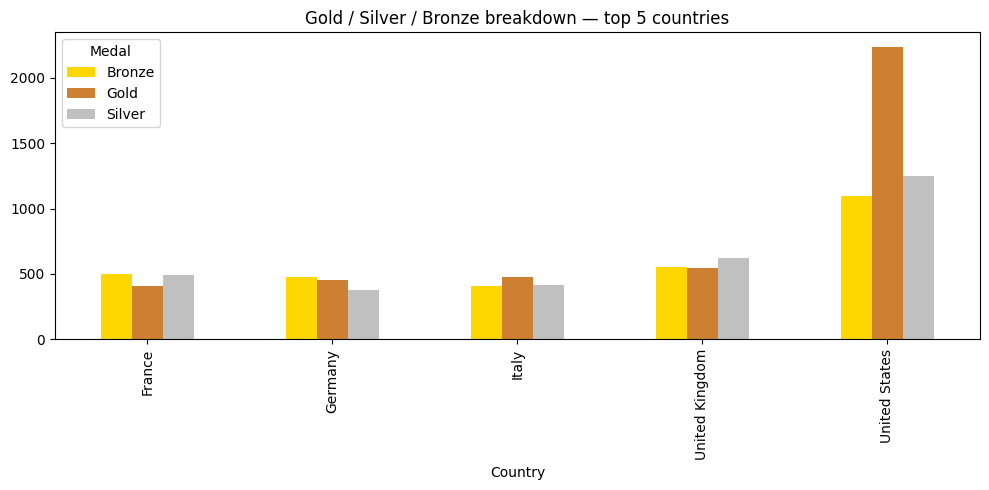

In [13]:
top5 = medals['Country'].value_counts().head(5).index.tolist()
subset = medals[medals['Country'].isin(top5)]
pivot = subset.groupby(['Country', 'Medal'])['Medal'].count().unstack().fillna(0)
pivot.plot(kind='bar', figsize=(10, 5), color=['gold','#cd7f32','silver'])
plt.title('Gold / Silver / Bronze breakdown — top 5 countries')
plt.tight_layout()
plt.show()

### Sport distribution

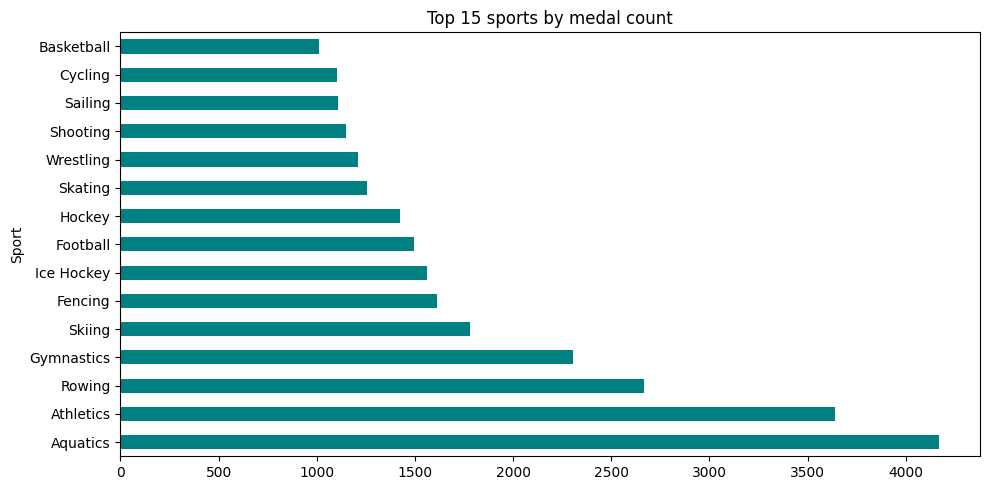

In [14]:
top_sports = medals['Sport'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
top_sports.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 sports by medal count')
plt.tight_layout()
plt.show()

### Summer vs Winter medals over time

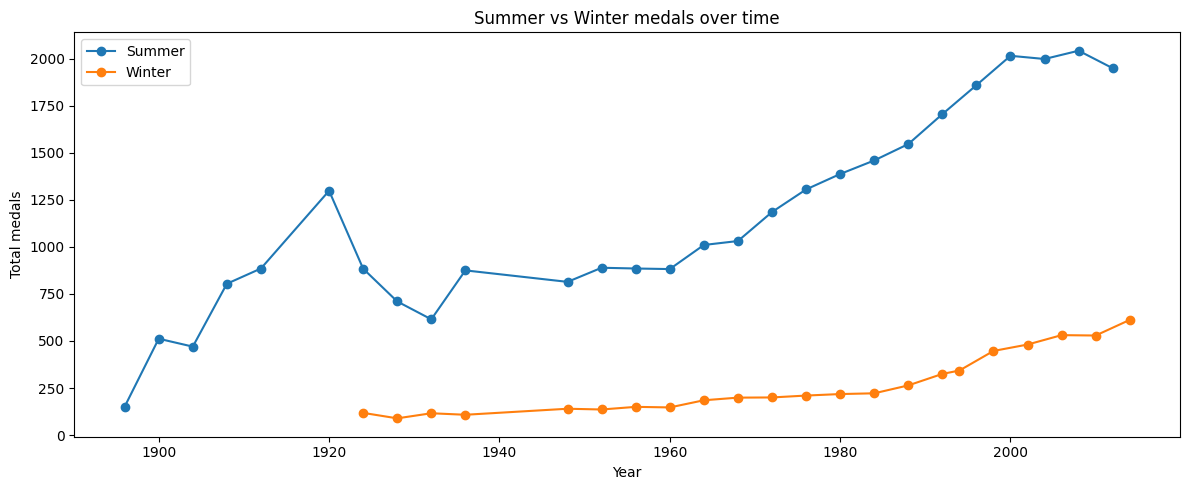

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
for season, grp in medals.groupby('Season'):
    yearly = grp.groupby('Year')['Medal'].count()
    ax.plot(yearly.index, yearly.values, marker='o', label=season)
ax.set_title('Summer vs Winter medals over time')
ax.set_xlabel('Year')
ax.set_ylabel('Total medals')
ax.legend()
plt.tight_layout()
plt.show()